<a href="https://colab.research.google.com/github/victorm0202/temas_selectos_CD_2026/blob/main/transfer_learning_CNN_texts.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Transfer Learning con CNN para textos

El código está basado en el artículo de Yoon Kim (2014): Convolutional neural networks for sentence classification.

Se implementan 3 variantes del modelo:

1. **CNN-rand**: embeddings inicializados aleatoriamente.
2. **CNN-static**: embeddings GloVe preentrenados y congelados.
3. **CNN-non-static**: embeddings GloVe preentrenados y ajustados durante el entrenamiento.

Usaremos los siguientes módulos:

- `datasets` se usa para cargar el dataset (AG News);
- `tokenizers` se usa para normalización, tokenización y construcción del vocabulario;
- PyTorch se usa para `Dataset`, `DataLoader`, la CNN y el entrenamiento;
- Gensim para descargar y cargar GloVe.



In [ ]:
# en colab
#%pip install -q datasets tokenizers gensim scikit-learn matplotlib

In [ ]:
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from datasets import load_dataset

from tokenizers import Tokenizer
from tokenizers.models import WordLevel
from tokenizers.normalizers import Sequence, Lowercase, NFD, StripAccents
from tokenizers.pre_tokenizers import Whitespace
from tokenizers.trainers import WordLevelTrainer

import gensim.downloader as api

from sklearn.metrics import accuracy_score, classification_report


SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

In [ ]:
import platform

if platform.system() == 'Darwin':
    mps_available = torch.backends.mps.is_available()
    mps_built = torch.backends.mps.is_built()
    if mps_available and mps_built:
        print('MPS available?', mps_available, 'MPS built?', mps_built)
        device = torch.device('mps')
    else:
        device = torch.device('cpu')
elif torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')

print('Device:', device)

MPS available? True MPS built? True
Device: mps


## El datset AG News de Hugging Face

AG News contiene cuatro categorías:

- World
- Sports
- Business
- Sci/Tech

In [ ]:
dataset = load_dataset("ag_news")

print(dataset)
print(dataset["train"][0])

label_names = ["World", "Sports", "Business", "Sci/Tech"]

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 120000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 7600
    })
})
{'text': "Wall St. Bears Claw Back Into the Black (Reuters) Reuters - Short-sellers, Wall Street's dwindling\\band of ultra-cynics, are seeing green again.", 'label': 2}


In [ ]:
MAX_TRAIN_SAMPLES = 30000 #None for full dataset
MAX_TEST_SAMPLES = 7600

train_hf = dataset["train"]
test_hf = dataset["test"]

if MAX_TRAIN_SAMPLES is not None:
    train_hf = train_hf.shuffle(seed=SEED).select(
        range(min(MAX_TRAIN_SAMPLES, len(train_hf)))
    )

if MAX_TEST_SAMPLES is not None:
    test_hf = test_hf.select(
        range(min(MAX_TEST_SAMPLES, len(test_hf)))
    )

print("Train:", len(train_hf))
print("Test :", len(test_hf))

Train: 30000
Test : 7600


# Tokenizador WordLevel de Hugging Face

`texto → normalización → separación en palabras → vocabulario → token IDs`

Usaremos un modelo `WordLevel`, que conserva una representación a nivel de palabra y por tanto es compatible conceptualmente con GloVe.

Esto es importante porque los vectores GloVe (y word2vec) están asociados a palabras completas. Tokenizadores subword como WordPiece o BPE producirían tokens que normalmente no tendrían un vector GloVe correspondiente.

In [ ]:
tokenizer = Tokenizer(
    WordLevel(unk_token="<unk>")
)

tokenizer.normalizer = Sequence([
    NFD(),
    Lowercase(),
    StripAccents()
])

tokenizer.pre_tokenizer = Whitespace()

trainer = WordLevelTrainer(
    special_tokens=["<pad>", "<unk>"],
    min_frequency=2
)

tokenizer.train_from_iterator(
    (example["text"] for example in train_hf),
    trainer=trainer
)

print("Tokenizer trained.")

Tokenizer trained.


Inspección del tokenizador

In [ ]:
example_text = train_hf[0]["text"]
encoding = tokenizer.encode(example_text)

print("Original text:")
print(example_text)

print("\nTokens:")
print(encoding.tokens[:30])

print("\nToken IDs:")
print(encoding.ids[:30])

Original text:
Bangladesh paralysed by strikes Opposition activists have brought many towns and cities in Bangladesh to a halt, the day after 18 people died in explosions at a political rally.

Tokens:
['bangladesh', 'paralysed', 'by', 'strikes', 'opposition', 'activists', 'have', 'brought', 'many', 'towns', 'and', 'cities', 'in', 'bangladesh', 'to', 'a', 'halt', ',', 'the', 'day', 'after', '18', 'people', 'died', 'in', 'explosions', 'at', 'a', 'political', 'rally']

Token IDs:
[1896, 18680, 27, 2343, 682, 3412, 47, 1593, 341, 6260, 11, 1873, 9, 1896, 6, 7, 1880, 4, 2, 133, 38, 492, 124, 852, 9, 3640, 23, 7, 580, 745]


## Obtener el vocabulario

El vocabulario ya no se construye manualmente: lo obtenemos directamente del tokenizador.

Se utilizan:

- `<pad>` para padding;
- `<unk>` para palabras fuera del vocabulario.

In [ ]:
stoi = tokenizer.get_vocab()

PAD_IDX = stoi["<pad>"]
UNK_IDX = stoi["<unk>"]

print("Vocabulary size:", len(stoi))
print("PAD_IDX:", PAD_IDX)
print("UNK_IDX:", UNK_IDX)

sample_vocab = list(stoi.items())[:20]
print("\nSample vocabulary entries:")
print(sample_vocab)

Vocabulary size: 25742
PAD_IDX: 0
UNK_IDX: 1

Sample vocabulary entries:
[('local', 762), ('christians', 9554), ('village', 4303), ('cowher', 14959), ('schwartz', 24457), ('tribunal', 3810), ('spearheaded', 19253), ('gram', 22176), ('william', 4587), ("''", 5521), ('rumour', 16097), ('mortgage', 1339), ('profusely', 23974), ('sooners', 5657), ('assaulting', 10888), ('clearer', 17151), ('brka', 20697), ('dis', 9601), ('plows', 15907), (")'", 12937)]


## Codificación y padding

`tokenizer.encode(text).ids` devuelve directamente la secuencia de índices enteros.

Después truncamos o completamos hasta `MAX_LEN`.

In [ ]:
MAX_LEN = 100

def encode_text(text, max_len=MAX_LEN):
    ids = tokenizer.encode(text).ids
    ids = ids[:max_len]
    if len(ids) < max_len:
        ids += [PAD_IDX] * (max_len - len(ids))

    return ids


encoded = encode_text(example_text)

print("Encoded length:", len(encoded))
print("First IDs:", encoded[:30])

Encoded length: 100
First IDs: [1896, 18680, 27, 2343, 682, 3412, 47, 1593, 341, 6260, 11, 1873, 9, 1896, 6, 7, 1880, 4, 2, 133, 38, 492, 124, 852, 9, 3640, 23, 7, 580, 745]


## El Dataset

In [ ]:
class AGNewsTorchDataset(Dataset):
    def __init__(self, hf_dataset):
        self.data = hf_dataset

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]

        input_ids = torch.tensor(
            encode_text(item["text"]),
            dtype=torch.long
        )

        label = torch.tensor(
            item["label"],
            dtype=torch.long
        )

        return input_ids, label


train_dataset = AGNewsTorchDataset(train_hf)
test_dataset = AGNewsTorchDataset(test_hf)

x, y = train_dataset[0]

print("Input shape:", x.shape)
print("Label:", y.item(), label_names[y.item()])

Input shape: torch.Size([100])
Label: 0 World


## DataLoaders

In [ ]:
BATCH_SIZE = 64

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

xb, yb = next(iter(train_loader))

print("Batch X:", xb.shape)
print("Batch y:", yb.shape)

Batch X: torch.Size([64, 100])
Batch y: torch.Size([64])


# GloVe embeddings

Usaremos `glove-wiki-gigaword-100`, con vectores de dimensión 100.

La primera ejecución descargará los embeddings.

In [ ]:
glove = api.load("glove-wiki-gigaword-100")

EMBED_DIM = glove.vector_size

print("Embedding dimension:", EMBED_DIM)
print("Example vector shape:", glove["computer"].shape)

[==================================================] 100.0% 128.1/128.1MB downloaded
Embedding dimension: 100
Example vector shape: (100,)


## Construcción de la matriz de embeddings

Cada token del vocabulario del tokenizador se intenta asociar con su correspondiente vector GloVe.

Como usamos `WordLevel`, la mayoría de los tokens léxicos son palabras completas, lo que hace posible esta alineación.

Las palabras que no aparecen en GloVe se inicializan con valores aleatorios pequeños.

In [ ]:
def build_embedding_matrix(stoi, pretrained_vectors, embed_dim):
    matrix = np.random.normal(
        loc=0.0,
        scale=0.05,
        size=(len(stoi), embed_dim)
    ).astype(np.float32)

    matrix[PAD_IDX] = np.zeros(embed_dim, dtype=np.float32)

    found = 0

    for word, idx in stoi.items():
        if word in ("<pad>", "<unk>"):
            continue

        if word in pretrained_vectors:
            matrix[idx] = pretrained_vectors[word]
            found += 1

    coverage = found / max(1, len(stoi) - 2)

    print(f"Words found in GloVe: {found:,}")
    print(f"Vocabulary coverage: {coverage:.2%}")

    return torch.tensor(matrix)


embedding_matrix = build_embedding_matrix(
    stoi,
    glove,
    EMBED_DIM
)

print("Embedding matrix:", embedding_matrix.shape)

Words found in GloVe: 25,024
Vocabulary coverage: 97.22%
Embedding matrix: torch.Size([25742, 100])


# TextCNN

La arquitectura usa varios tamaños de kernel para capturar patrones locales de diferente longitud.

Para cada kernel:

`Embedding → Conv1D → ReLU → Global Max Pooling`

Después se concatenan las representaciones y se aplica:

`Dropout → Linear`

In [ ]:
class TextCNN(nn.Module):
    def __init__(
        self,
        vocab_size,
        embed_dim,
        num_classes,
        kernel_sizes=(3, 4, 5),
        num_filters=100,
        dropout=0.5,
        pretrained_embeddings=None,
        freeze_embeddings=False
    ):
        super().__init__()

        if pretrained_embeddings is None:
            self.embedding = nn.Embedding(
                vocab_size,
                embed_dim,
                padding_idx=PAD_IDX
            )
        else:
            self.embedding = nn.Embedding.from_pretrained(
                pretrained_embeddings,
                freeze=freeze_embeddings,
                padding_idx=PAD_IDX
            )

        self.convs = nn.ModuleList([
            nn.Conv1d(
                in_channels=embed_dim,
                out_channels=num_filters,
                kernel_size=k
            )
            for k in kernel_sizes
        ])

        self.dropout = nn.Dropout(dropout)

        self.fc = nn.Linear(
            num_filters * len(kernel_sizes),
            num_classes
        )

    def forward(self, x):
        # x: (batch, seq_len)

        x = self.embedding(x)
        # (batch, seq_len, embed_dim)

        x = x.transpose(1, 2)
        # Conv1D espera (batch, channels, sequence_length)

        pooled_outputs = []

        for conv in self.convs:
            h = torch.relu(conv(x))
            # (batch, num_filters, conv_seq_len)

            h = torch.max(h, dim=2).values
            # Global max pooling

            pooled_outputs.append(h)

        x = torch.cat(pooled_outputs, dim=1)
        x = self.dropout(x)

        return self.fc(x)

## Funciones de entrenamiento y evaluación

In [ ]:
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()

    total_loss = 0.0
    all_preds = []
    all_labels = []

    for inputs, labels in loader:
        inputs = inputs.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        logits = model(inputs)
        loss = criterion(logits, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item() * inputs.size(0)

        preds = logits.argmax(dim=1)

        all_preds.extend(preds.detach().cpu().numpy())
        all_labels.extend(labels.detach().cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    accuracy = accuracy_score(all_labels, all_preds)

    return avg_loss, accuracy


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()

    total_loss = 0.0
    all_preds = []
    all_labels = []

    for inputs, labels in loader:
        inputs = inputs.to(device)
        labels = labels.to(device)

        logits = model(inputs)
        loss = criterion(logits, labels)

        total_loss += loss.item() * inputs.size(0)

        preds = logits.argmax(dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    accuracy = accuracy_score(all_labels, all_preds)

    return avg_loss, accuracy, all_labels, all_preds

Una corrida del entrenamiento y ajuste

In [ ]:
def run_experiment(
    name,
    pretrained_embeddings=None,
    freeze_embeddings=False,
    epochs=5,
    learning_rate=1e-3
):
    print("=" * 70)
    print(name)
    print("=" * 70)

    model = TextCNN(
        vocab_size=len(stoi),
        embed_dim=EMBED_DIM,
        num_classes=4,
        pretrained_embeddings=pretrained_embeddings,
        freeze_embeddings=freeze_embeddings
    ).to(device)

    criterion = nn.CrossEntropyLoss()

    optimizer = torch.optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=learning_rate
    )

    history = {
        "train_loss": [],
        "train_acc": [],
        "test_loss": [],
        "test_acc": []
    }

    for epoch in range(1, epochs + 1):
        train_loss, train_acc = train_one_epoch(
            model,
            train_loader,
            optimizer,
            criterion
        )

        test_loss, test_acc, _, _ = evaluate(
            model,
            test_loader,
            criterion
        )

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["test_loss"].append(test_loss)
        history["test_acc"].append(test_acc)

        print(
            f"Epoch {epoch:02d} | "
            f"train loss={train_loss:.4f} | "
            f"train acc={train_acc:.4f} | "
            f"test loss={test_loss:.4f} | "
            f"test acc={test_acc:.4f}"
        )

    return model, history

# Experimento 1 — CNN-rand

Los embeddings se inicializan aleatoriamente y se aprenden completamente a partir de AG News.

Este modelo **no utiliza transfer learning** y sirve como baseline.

In [ ]:
model_rand, hist_rand = run_experiment(
    name="CNN-rand",
    pretrained_embeddings=None,
    freeze_embeddings=False,
    epochs=5
)

CNN-rand
Epoch 01 | train loss=1.0040 | train acc=0.5754 | test loss=0.5831 | test acc=0.7864
Epoch 02 | train loss=0.5524 | train acc=0.7946 | test loss=0.4140 | test acc=0.8553
Epoch 03 | train loss=0.3937 | train acc=0.8618 | test loss=0.3658 | test acc=0.8717
Epoch 04 | train loss=0.2999 | train acc=0.8962 | test loss=0.3537 | test acc=0.8803
Epoch 05 | train loss=0.2352 | train acc=0.9193 | test loss=0.3455 | test acc=0.8853


# Experimento 2 — CNN-static

Los embeddings se inicializan con GloVe y permanecen **congelados**.

Aquí el conocimiento aprendido previamente por GloVe se transfiere al nuevo problema, pero los vectores no cambian.

In [ ]:
model_static, hist_static = run_experiment(
    name="CNN-static (GloVe frozen)",
    pretrained_embeddings=embedding_matrix,
    freeze_embeddings=True,
    epochs=5
)

CNN-static (GloVe frozen)
Epoch 01 | train loss=0.4106 | train acc=0.8604 | test loss=0.3013 | test acc=0.8995
Epoch 02 | train loss=0.2904 | train acc=0.9031 | test loss=0.2823 | test acc=0.9011
Epoch 03 | train loss=0.2598 | train acc=0.9118 | test loss=0.2789 | test acc=0.9038
Epoch 04 | train loss=0.2337 | train acc=0.9208 | test loss=0.2768 | test acc=0.9070
Epoch 05 | train loss=0.2149 | train acc=0.9274 | test loss=0.2704 | test acc=0.9086


# Experimento 3 — CNN-non-static

Los embeddings también se inicializan con GloVe, pero ahora son **entrenables**.

Esto corresponde a una forma sencilla de **fine-tuning**.

In [ ]:
model_nonstatic, hist_nonstatic = run_experiment(
    name="CNN-non-static (GloVe fine-tuning)",
    pretrained_embeddings=embedding_matrix,
    freeze_embeddings=False,
    epochs=5,
    learning_rate=1e-3
)

CNN-non-static (GloVe fine-tuning)
Epoch 01 | train loss=0.3914 | train acc=0.8670 | test loss=0.2735 | test acc=0.9075
Epoch 02 | train loss=0.2403 | train acc=0.9197 | test loss=0.2593 | test acc=0.9116
Epoch 03 | train loss=0.1831 | train acc=0.9394 | test loss=0.2627 | test acc=0.9117
Epoch 04 | train loss=0.1368 | train acc=0.9551 | test loss=0.2633 | test acc=0.9150
Epoch 05 | train loss=0.0957 | train acc=0.9696 | test loss=0.2883 | test acc=0.9154


# Resultados

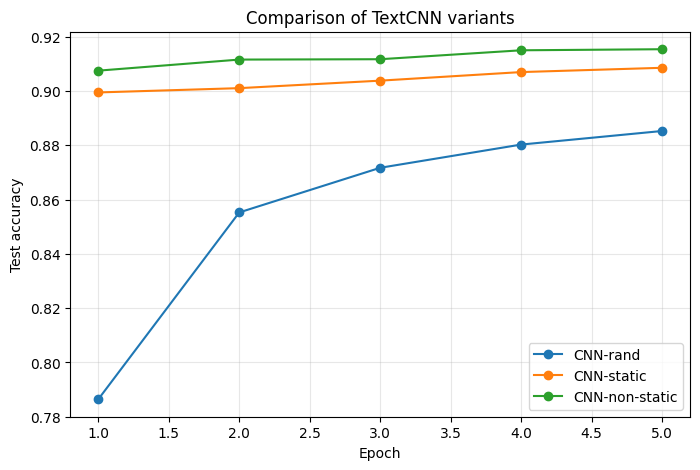

In [ ]:
epochs = range(1, len(hist_rand["test_acc"]) + 1)

plt.figure(figsize=(8, 5))

plt.plot(epochs, hist_rand["test_acc"], marker="o", label="CNN-rand")
plt.plot(epochs, hist_static["test_acc"], marker="o", label="CNN-static")
plt.plot(epochs, hist_nonstatic["test_acc"], marker="o", label="CNN-non-static")

plt.xlabel("Epoch")
plt.ylabel("Test accuracy")
plt.title("Comparison of TextCNN variants")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Evaluación final

In [ ]:
criterion = nn.CrossEntropyLoss()

results = {}

for name, model in {
    "CNN-rand": model_rand,
    "CNN-static": model_static,
    "CNN-non-static": model_nonstatic
}.items():

    loss, acc, labels, preds = evaluate(
        model,
        test_loader,
        criterion
    )

    results[name] = acc

    print(f"\n{name}")
    print(f"Accuracy: {acc:.4f}")
    print(
        classification_report(
            labels,
            preds,
            target_names=label_names,
            digits=4
        )
    )


CNN-rand
Accuracy: 0.8853
              precision    recall  f1-score   support

       World     0.9007    0.8832    0.8918      1900
      Sports     0.9294    0.9563    0.9427      1900
    Business     0.8498    0.8458    0.8478      1900
    Sci/Tech     0.8599    0.8558    0.8578      1900

    accuracy                         0.8853      7600
   macro avg     0.8849    0.8853    0.8850      7600
weighted avg     0.8849    0.8853    0.8850      7600


CNN-static
Accuracy: 0.9086
              precision    recall  f1-score   support

       World     0.9049    0.9211    0.9129      1900
      Sports     0.9648    0.9668    0.9658      1900
    Business     0.9061    0.8384    0.8710      1900
    Sci/Tech     0.8608    0.9079    0.8837      1900

    accuracy                         0.9086      7600
   macro avg     0.9091    0.9086    0.9083      7600
weighted avg     0.9091    0.9086    0.9083      7600


CNN-non-static
Accuracy: 0.9154
              precision    recall  f1-sco

Resumen de resultados

In [ ]:
for name, acc in sorted(
    results.items(),
    key=lambda x: x[1],
    reverse=True
):
    print(f"{name:20s}: {acc:.4f}")

CNN-non-static      : 0.9154
CNN-static          : 0.9086
CNN-rand            : 0.8853


Un ejemplo de predicción sobre texto nuevo

In [ ]:
@torch.no_grad()
def predict_text(model, text):
    model.eval()

    ids = torch.tensor(
        encode_text(text),
        dtype=torch.long
    ).unsqueeze(0).to(device)

    logits = model(ids)
    probs = torch.softmax(logits, dim=1).squeeze(0)

    pred_idx = probs.argmax().item()

    return {
        "label": label_names[pred_idx],
        "probability": probs[pred_idx].item(),
        "all_probabilities": {
            label_names[i]: probs[i].item()
            for i in range(len(label_names))
        }
    }


text = "Apple announces a new processor for its next generation computers."

predict_text(model_nonstatic, text)

{'label': 'Sci/Tech',
 'probability': 0.9644530415534973,
 'all_probabilities': {'World': 0.0006898391293361783,
  'Sports': 7.868710781622212e-06,
  'Business': 0.03484930098056793,
  'Sci/Tech': 0.9644530415534973}}